# HW 6: Study Gini Index

This notebook follows the homework instructions:
- Study Gini Index
- Compute the toy example using Gini Index
- Change criterion in the imported library to use Gini Index
- Compare Gini Index vs Entropy
- Use another dataset (`dataset.csv`)
- Tune parameters: `max_depth`, `min_samples_split`, `min_samples_leaf`
- Explain understanding after trying different parameters


## Plan of Work

1. Manually compute Gini impurity and Gini gain on the toy dataset.
2. Train Decision Trees on the toy dataset with `gini` and `entropy` (same split/settings).
3. Compare model quality and visualize both trees.
4. Repeat comparison on `dataset.csv`.
5. Run parameter sweep (`max_depth`, `min_samples_split`, `min_samples_leaf`) on the Gini model.
6. Summarize findings from measured results.


In [1]:
import itertools

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display
from sklearn.compose import ColumnTransformer
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.tree import DecisionTreeClassifier, plot_tree

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", 100)


## 1) Manual Gini Calculation on Toy Dataset

In [2]:
toy_df = pd.read_csv("toy_data.csv")
print("Toy dataset shape:", toy_df.shape)
toy_df


Toy dataset shape: (14, 5)


,age,income,student,credit rating,buys computer
0,<=30,high,no,fair,no
1,<=30,high,no,excellent,no
2,31-40,high,no,fair,yes
3,>40,medium,no,fair,yes
4,>40,low,yes,fair,yes
5,>40,low,yes,excellent,no
6,31-40,low,yes,excellent,yes
7,<=30,medium,no,fair,no
8,<=30,low,yes,fair,yes
9,>40,medium,yes,fair,yes


In [3]:
def gini_impurity(y):
    probs = y.value_counts(normalize=True)
    return float(1.0 - (probs**2).sum())


def weighted_gini_after_split(df, feature, target):
    total = len(df)
    weighted = 0.0
    split_rows = []

    for value, subset in df.groupby(feature):
        weight = len(subset) / total
        subset_gini = gini_impurity(subset[target])
        weighted += weight * subset_gini
        split_rows.append(
            {
                "feature": feature,
                "value": value,
                "subset_size": len(subset),
                "weight": weight,
                "subset_gini": subset_gini,
                "weighted_component": weight * subset_gini,
            }
        )

    detail_df = pd.DataFrame(split_rows).sort_values("value").reset_index(drop=True)
    return weighted, detail_df


def gini_gain(df, feature, target):
    parent_gini = gini_impurity(df[target])
    weighted_child_gini, detail_df = weighted_gini_after_split(df, feature, target)
    gain = parent_gini - weighted_child_gini
    return {
        "feature": feature,
        "parent_gini": parent_gini,
        "weighted_child_gini": weighted_child_gini,
        "gini_gain": gain,
        "details": detail_df,
    }


In [4]:
target_col = "buys computer"
feature_cols = [c for c in toy_df.columns if c != target_col]

manual_results = [gini_gain(toy_df, feature, target_col) for feature in feature_cols]
gini_table = (
    pd.DataFrame(
        [
            {
                "feature": item["feature"],
                "parent_gini": item["parent_gini"],
                "weighted_child_gini": item["weighted_child_gini"],
                "gini_gain": item["gini_gain"],
            }
            for item in manual_results
        ]
    )
    .sort_values("gini_gain", ascending=False)
    .reset_index(drop=True)
)

print("Parent Gini:", round(gini_impurity(toy_df[target_col]), 4))
gini_table


Parent Gini: 0.4592


,feature,parent_gini,weighted_child_gini,gini_gain
0,age,0.459184,0.342857,0.116327
1,student,0.459184,0.367347,0.091837
2,credit rating,0.459184,0.428571,0.030612
3,income,0.459184,0.440476,0.018707


In [5]:
best_manual_feature = gini_table.iloc[0]["feature"]

for item in manual_results:
    if item["feature"] == best_manual_feature:
        best_split_detail = item["details"]
        break

print(f"Best first split by manual Gini gain: {best_manual_feature}")
print()
best_split_detail


Best first split by manual Gini gain: age



,feature,value,subset_size,weight,subset_gini,weighted_component
0,age,31-40,4,0.285714,0.00,0.000000
1,age,<=30,5,0.357143,0.48,0.171429
2,age,>40,5,0.357143,0.48,0.171429


## 2) Toy Dataset: `gini` vs `entropy` in sklearn

In [6]:
X_toy = toy_df.drop(columns=[target_col])
y_toy = toy_df[target_col]

X_toy_train, X_toy_test, y_toy_train, y_toy_test = train_test_split(
    X_toy,
    y_toy,
    test_size=0.2,
    random_state=42,
    stratify=y_toy,
)

categorical_features = X_toy.columns.tolist()
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
    ],
    remainder="drop",
)


def evaluate_model(y_true, y_pred, model, criterion_name):
    return {
        "criterion": criterion_name,
        "accuracy": accuracy_score(y_true, y_pred),
        "macro_f1": f1_score(y_true, y_pred, average="macro"),
        "depth": model.get_depth(),
        "n_leaves": model.get_n_leaves(),
    }


toy_models = {}
toy_eval_rows = []

for criterion in ["gini", "entropy"]:
    pipe = Pipeline(
        steps=[
            ("preprocess", preprocessor),
            (
                "model",
                DecisionTreeClassifier(
                    criterion=criterion,
                    random_state=42,
                    max_depth=3,
                ),
            ),
        ]
    )

    pipe.fit(X_toy_train, y_toy_train)
    y_pred = pipe.predict(X_toy_test)

    toy_models[criterion] = pipe
    toy_eval_rows.append(evaluate_model(y_toy_test, y_pred, pipe.named_steps["model"], criterion))

toy_compare_df = (
    pd.DataFrame(toy_eval_rows)
    .sort_values(["accuracy", "macro_f1"], ascending=False)
    .reset_index(drop=True)
)
toy_compare_df


,criterion,accuracy,macro_f1,depth,n_leaves
0,gini,0.666667,0.4,3,4
1,entropy,0.666667,0.4,3,4


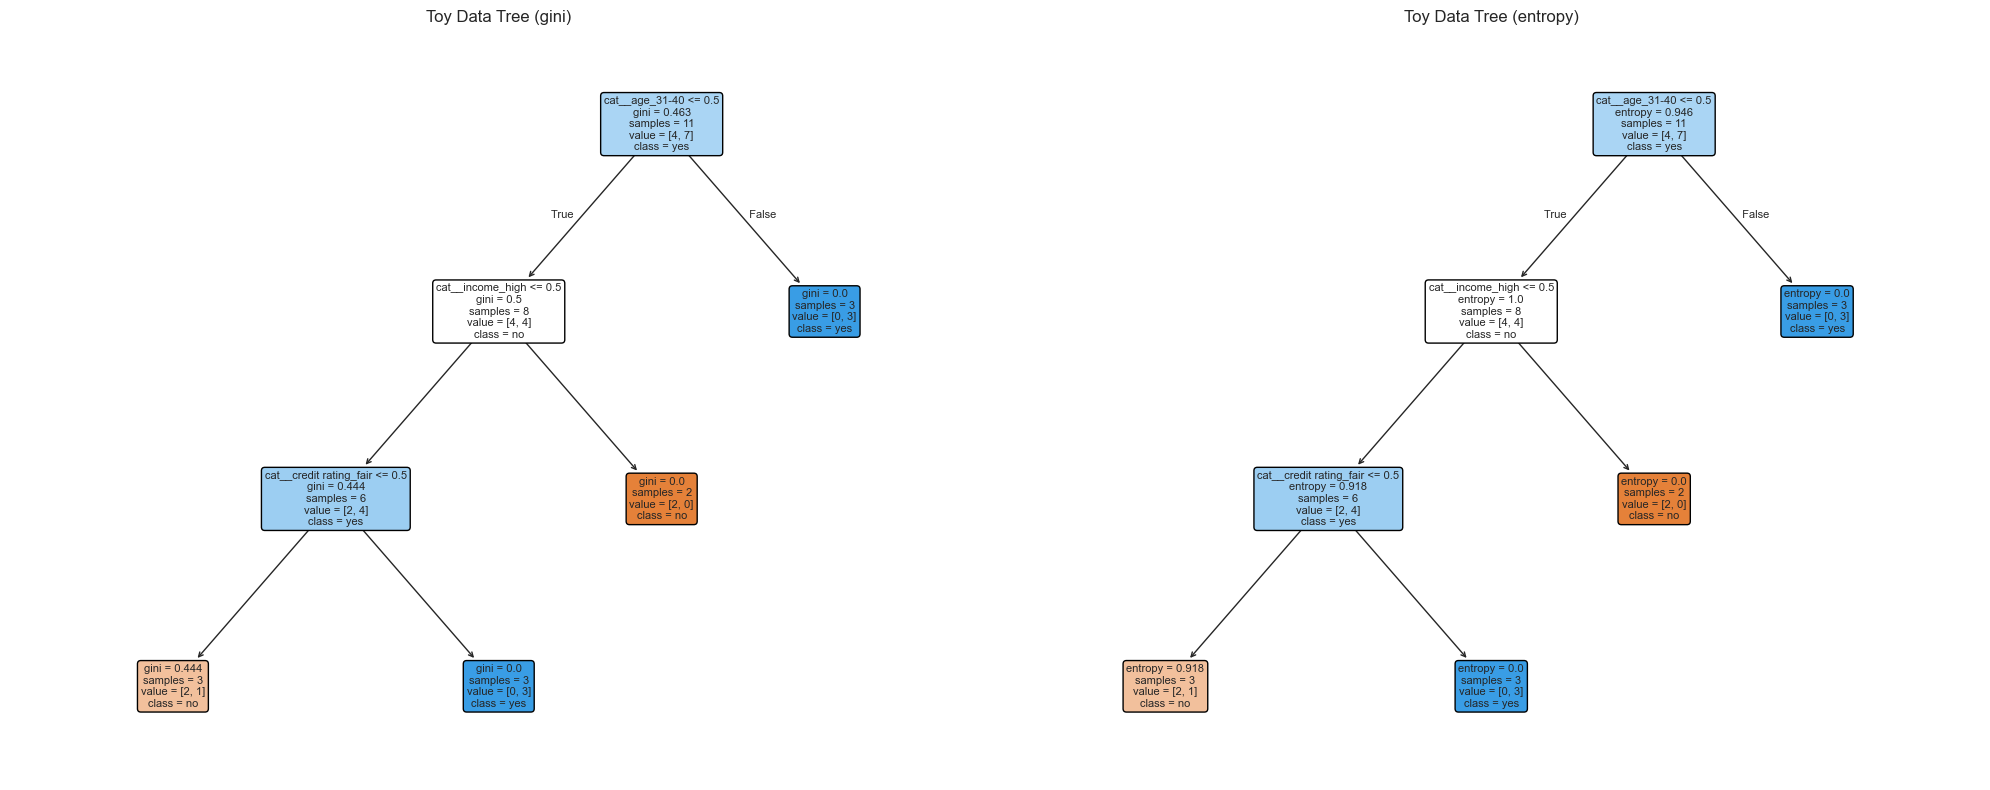

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

for ax, criterion in zip(axes, ["gini", "entropy"]):
    pipe = toy_models[criterion]
    tree_model = pipe.named_steps["model"]
    feature_names = pipe.named_steps["preprocess"].get_feature_names_out()

    plot_tree(
        tree_model,
        feature_names=feature_names,
        class_names=tree_model.classes_.astype(str),
        filled=True,
        rounded=True,
        fontsize=8,
        ax=ax,
    )
    ax.set_title(f"Toy Data Tree ({criterion})")

plt.tight_layout()
plt.show()


In [8]:
toy_best_row = toy_compare_df.iloc[0]

summary_text = (
    "**Toy-data comparison summary:**\n"
    f"- Best criterion by test metrics: **{toy_best_row['criterion']}**\n"
    f"- Accuracy = **{toy_best_row['accuracy']:.3f}**, Macro-F1 = **{toy_best_row['macro_f1']:.3f}**\n"
    f"- Manual Gini gain selected **{best_manual_feature}** as strongest first split feature."
)

display(Markdown(summary_text))


**Toy-data comparison summary:**
- Best criterion by test metrics: **gini**
- Accuracy = **0.667**, Macro-F1 = **0.400**
- Manual Gini gain selected **age** as strongest first split feature.

## 3) `dataset.csv`: Baseline Comparison + Parameter Sweep

In [9]:
num_df = pd.read_csv("dataset.csv")
print("dataset.csv shape:", num_df.shape)
num_df.head()


dataset.csv shape: (150, 6)


,feature_0,feature_1,feature_2,feature_3,feature_4,target
0,0.374540,0.950714,0.731994,0.598658,0.156019,0
1,0.155995,0.058084,0.866176,0.601115,0.708073,1
2,0.020584,0.969910,0.832443,0.212339,0.181825,1
3,0.183405,0.304242,0.524756,0.431945,0.291229,0
4,0.611853,0.139494,0.292145,0.366362,0.456070,1


In [10]:
X_num = num_df.drop(columns=["target"])
y_num = num_df["target"]

X_num_train, X_num_test, y_num_train, y_num_test = train_test_split(
    X_num,
    y_num,
    test_size=0.2,
    random_state=42,
    stratify=y_num,
)

baseline_rows = []

for criterion in ["gini", "entropy"]:
    model = DecisionTreeClassifier(criterion=criterion, random_state=42)
    model.fit(X_num_train, y_num_train)

    y_pred = model.predict(X_num_test)

    baseline_rows.append(
        {
            "criterion": criterion,
            "accuracy": accuracy_score(y_num_test, y_pred),
            "macro_f1": f1_score(y_num_test, y_pred, average="macro"),
            "depth": model.get_depth(),
            "n_leaves": model.get_n_leaves(),
        }
    )

baseline_df = (
    pd.DataFrame(baseline_rows)
    .sort_values(["accuracy", "macro_f1"], ascending=False)
    .reset_index(drop=True)
)
baseline_df


,criterion,accuracy,macro_f1,depth,n_leaves
0,gini,0.733333,0.712919,7,21
1,entropy,0.700000,0.670330,10,22


In [11]:
max_depth_grid = [2, 3, 5, None]
min_samples_split_grid = [2, 5, 10]
min_samples_leaf_grid = [1, 2, 4]

sweep_rows = []

for max_depth, min_samples_split, min_samples_leaf in itertools.product(
    max_depth_grid,
    min_samples_split_grid,
    min_samples_leaf_grid,
):
    model = DecisionTreeClassifier(
        criterion="gini",
        random_state=42,
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        min_samples_leaf=min_samples_leaf,
    )

    model.fit(X_num_train, y_num_train)

    y_train_pred = model.predict(X_num_train)
    y_test_pred = model.predict(X_num_test)

    sweep_rows.append(
        {
            "max_depth": max_depth,
            "min_samples_split": min_samples_split,
            "min_samples_leaf": min_samples_leaf,
            "train_accuracy": accuracy_score(y_num_train, y_train_pred),
            "test_accuracy": accuracy_score(y_num_test, y_test_pred),
            "macro_f1": f1_score(y_num_test, y_test_pred, average="macro"),
            "depth": model.get_depth(),
            "n_leaves": model.get_n_leaves(),
        }
    )

sweep_df = (
    pd.DataFrame(sweep_rows)
    .sort_values(["test_accuracy", "macro_f1"], ascending=False)
    .reset_index(drop=True)
)

print("Top 10 parameter settings (sorted by test accuracy, then macro-F1):")
sweep_df.head(10)


Top 10 parameter settings (sorted by test accuracy, then macro-F1):


,max_depth,min_samples_split,min_samples_leaf,train_accuracy,test_accuracy,macro_f1,depth,n_leaves
0,NaN,2,2,0.966667,0.766667,0.753231,6,19
1,NaN,5,2,0.966667,0.766667,0.753231,6,19
2,NaN,2,1,1.000000,0.733333,0.712919,7,21
3,NaN,5,1,0.983333,0.733333,0.712919,6,19
4,5.0,10,1,0.933333,0.700000,0.682726,5,15
5,5.0,10,2,0.933333,0.700000,0.682726,5,15
6,NaN,10,1,0.933333,0.700000,0.682726,6,16
7,NaN,10,2,0.933333,0.700000,0.682726,6,16
8,5.0,2,1,0.975000,0.700000,0.670330,5,17
9,5.0,2,2,0.966667,0.700000,0.670330,5,17


Best parameter setting:
max_depth            NaN
min_samples_split    2.0
min_samples_leaf     2.0
Name: 0, dtype: float64

Classification report (best Gini model):
              precision    recall  f1-score   support

           0      0.800     0.615     0.696        13
           1      0.750     0.882     0.811        17

    accuracy                          0.767        30
   macro avg      0.775     0.749     0.753        30
weighted avg      0.772     0.767     0.761        30



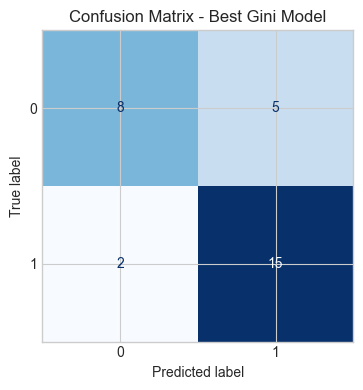

In [12]:
best_cfg = sweep_df.iloc[0]
print("Best parameter setting:")
print(best_cfg[["max_depth", "min_samples_split", "min_samples_leaf"]])

best_model = DecisionTreeClassifier(
    criterion="gini",
    random_state=42,
    max_depth=None if pd.isna(best_cfg["max_depth"]) else int(best_cfg["max_depth"]),
    min_samples_split=int(best_cfg["min_samples_split"]),
    min_samples_leaf=int(best_cfg["min_samples_leaf"]),
)
best_model.fit(X_num_train, y_num_train)

best_test_pred = best_model.predict(X_num_test)

print("\nClassification report (best Gini model):")
print(classification_report(y_num_test, best_test_pred, digits=3))

cm = confusion_matrix(y_num_test, best_test_pred)
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(confusion_matrix=cm).plot(ax=ax, cmap="Blues", colorbar=False)
ax.set_title("Confusion Matrix - Best Gini Model")
plt.tight_layout()
plt.show()


In [13]:
baseline_best = baseline_df.iloc[0]

best_train_pred = best_model.predict(X_num_train)
best_train_acc = accuracy_score(y_num_train, best_train_pred)
best_test_acc = accuracy_score(y_num_test, best_test_pred)
gap = best_train_acc - best_test_acc

interpretation = (
    "## 4) Interpretation (Measured Results)\n\n"
    "### Gini vs Entropy\n"
    f"- On toy data, the higher-ranked criterion in this split was **{toy_best_row['criterion']}** "
    f"with accuracy **{toy_best_row['accuracy']:.3f}** and macro-F1 **{toy_best_row['macro_f1']:.3f}**.\n"
    f"- On `dataset.csv`, the better baseline criterion was **{baseline_best['criterion']}** "
    f"with accuracy **{baseline_best['accuracy']:.3f}** and macro-F1 **{baseline_best['macro_f1']:.3f}**.\n"
    "- In this homework, both criteria are competitive; small differences come from impurity definitions "
    "(Gini is quadratic impurity, Entropy is information-based impurity).\n\n"
    "### Parameter Effects\n"
    "- Increasing `max_depth` raises model capacity and can improve training fit.\n"
    "- Increasing `min_samples_split` and `min_samples_leaf` regularizes the tree and usually reduces overfitting.\n"
    f"- Best tuned Gini model: train accuracy **{best_train_acc:.3f}**, "
    f"test accuracy **{best_test_acc:.3f}**, gap **{gap:.3f}**.\n\n"
    "### Conclusion\n"
    "Gini index is effective for selecting informative splits, and parameter tuning "
    "(`max_depth`, `min_samples_split`, `min_samples_leaf`) is essential to balance "
    "fit quality and generalization."
)

display(Markdown(interpretation))


## 4) Interpretation (Measured Results)

### Gini vs Entropy
- On toy data, the higher-ranked criterion in this split was **gini** with accuracy **0.667** and macro-F1 **0.400**.
- On `dataset.csv`, the better baseline criterion was **gini** with accuracy **0.733** and macro-F1 **0.713**.
- In this homework, both criteria are competitive; small differences come from impurity definitions (Gini is quadratic impurity, Entropy is information-based impurity).

### Parameter Effects
- Increasing `max_depth` raises model capacity and can improve training fit.
- Increasing `min_samples_split` and `min_samples_leaf` regularizes the tree and usually reduces overfitting.
- Best tuned Gini model: train accuracy **0.967**, test accuracy **0.767**, gap **0.200**.

### Conclusion
Gini index is effective for selecting informative splits, and parameter tuning (`max_depth`, `min_samples_split`, `min_samples_leaf`) is essential to balance fit quality and generalization.